# Dynamic Nelson–Siegel (DNS) Yield Curve Model

This notebook walks through a single-date cross-sectional Nelson–Siegel fit, which is the building block for the Dynamic Nelson–Siegel model.

The workflow is:

1. Load Treasury yield data
2. Select one date and corresponding maturity yields
3. Compute Nelson–Siegel loadings
4. Estimate the factors using OLS
5. Reconstruct the fitted curve
6. Plot:
   - actual vs fitted yields
   - contribution of level, slope, and curvature factors

In [110]:
# Imports
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

In [111]:
# Fetch the data
df_yields = pd.read_csv("data/yields.csv", index_col=0, parse_dates=True).dropna()

# Format the data
df_yields.index = pd.to_datetime(df_yields.index, format="%Y-%m-%d")
df_yields = df_yields / 100.0

## Example of the Nelson-Siegel Yield Curve for one date

In [112]:
# Select one date for cross-sectional fitting
date = dt.datetime(2025, 9, 24)

# Maturities in years
tau = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30], dtype=float)

# Observed yields for the selected date
yields = df_yields.loc[date].to_numpy()

print("Selected date:", date.date())
print("Observed yields:", yields)

Selected date: 2025-09-24
Observed yields: [0.0418 0.0402 0.0382 0.0363 0.0357 0.036  0.037  0.0391 0.0416 0.0473
 0.0476]


In [113]:
def ns_loadings(tau, lbd):
    """
    Compute Nelson-Siegel factor loadings.

    Parameters
    ----------
    tau : array-like
        Maturities in years.
    lbd : float
        Decay parameter lambda.

    Returns
    -------
    np.ndarray
        Matrix with columns:
        [level loading, slope loading, curvature loading]
    """
    tau = np.asarray(tau, dtype=float)

    level = np.ones_like(tau)
    slope = (1 - np.exp(-lbd * tau)) / (lbd * tau)
    curvature = slope - np.exp(-lbd * tau)

    return np.column_stack([level, slope, curvature])

# Fixed lambda as in Diebold and Li (2006)
lbd = 0.0609

# Loading matrix
L = ns_loadings(tau, lbd)

# Estimate beta via least squares
beta, residuals, rank, s = np.linalg.lstsq(L, yields, rcond=None)

beta_0, beta_1, beta_2 = beta

print(f"Estimated beta_0 (level):     {beta_0:.6f}")
print(f"Estimated beta_1 (slope):     {beta_1:.6f}")
print(f"Estimated beta_2 (curvature): {beta_2:.6f}")

Estimated beta_0 (level):     0.084972
Estimated beta_1 (slope):     -0.046855
Estimated beta_2 (curvature): -0.047399


In [114]:
# Fitted yield curve
y_fit = L @ beta

# Individual factor contributions
level_contrib = beta_0 * L[:, 0]
slope_contrib = beta_1 * L[:, 1]
curvature_contrib = beta_2 * L[:, 2]

# Check decomposition
reconstructed = level_contrib + slope_contrib + curvature_contrib
np.allclose(y_fit, reconstructed)

True

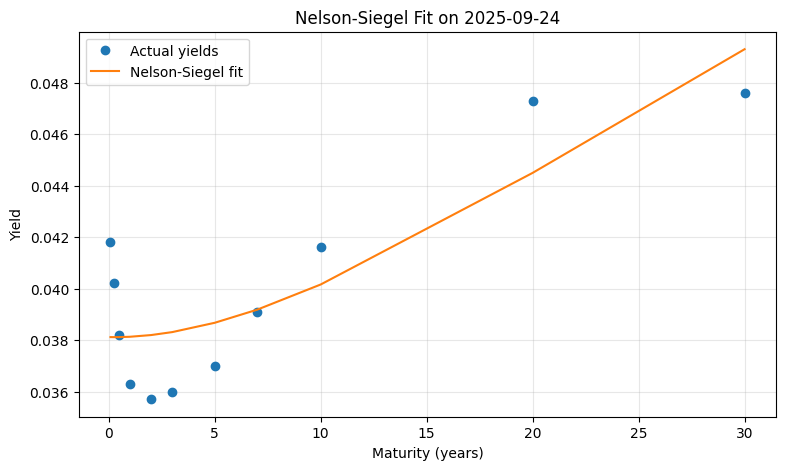

In [115]:
plt.figure(figsize=(9, 5))
plt.plot(tau, yields, 'o', label='Actual yields')
plt.plot(tau, y_fit, '-', label='Nelson-Siegel fit')

plt.xlabel("Maturity (years)")
plt.ylabel("Yield")
plt.title(f"Nelson-Siegel Fit on {date.date()}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

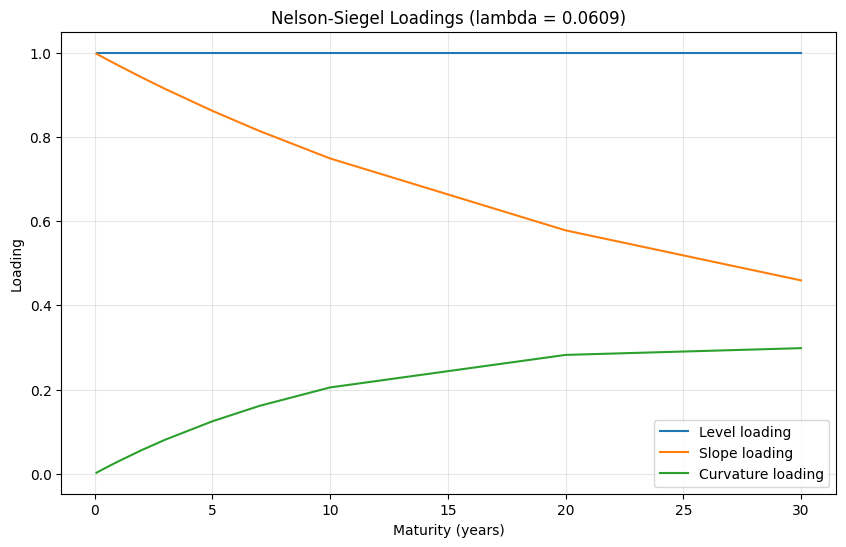

In [116]:
plt.figure(figsize=(10, 6))

plt.plot(tau, L[:, 0], label='Level loading')
plt.plot(tau, L[:, 1], label='Slope loading')
plt.plot(tau, L[:, 2], label='Curvature loading')

plt.xlabel("Maturity (years)")
plt.ylabel("Loading")
plt.title(f"Nelson-Siegel Loadings (lambda = {lbd})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Estimate Nelson–Siegel factors for all dates

Now extend the single-date cross-sectional fit across the full sample.

For each date in the dataset:

1. take the cross section of yields
2. fit the Nelson–Siegel coefficients using OLS
3. store the estimated level, slope, and curvature factors

This produces a time series of NS factors, which is the natural bridge from static Nelson–Siegel to Dynamic Nelson–Siegel.

In [117]:
# Reuse the same maturity grid and fixed lambda
L = ns_loadings(tau, lbd)

betas = []
fit_errors = []
dates = []

for current_date, row in df_yields.iterrows():
    y = row.to_numpy()

    # Estimate NS coefficients for this date
    beta_t, *_ = np.linalg.lstsq(L, y, rcond=None)

    # Fitted curve and RMSE
    y_fit_t = L @ beta_t
    rmse_t = np.sqrt(np.mean((y - y_fit_t) ** 2))

    betas.append(beta_t)
    fit_errors.append(rmse_t)
    dates.append(current_date)

# Store estimated factors in a DataFrame
df_betas = pd.DataFrame(
    betas,
    index=dates,
    columns=["Level", "Slope", "Curvature"]
)

# Store fit diagnostics
df_fit = pd.DataFrame(
    {"RMSE": fit_errors},
    index=dates
)

print("Estimated NS factors for all dates:")
display(df_betas.head())

print("Fit diagnostics:")
display(df_fit.head())

Estimated NS factors for all dates:


,Level,Slope,Curvature
2010-01-04,-0.070848,0.070386,0.279926
2010-01-05,-0.066651,0.065919,0.271230
2010-01-06,-0.067050,0.066171,0.275709
2010-01-07,-0.068454,0.067600,0.277685
2010-01-08,-0.065114,0.064058,0.272519


Fit diagnostics:


,RMSE
2010-01-04,0.001377
2010-01-05,0.001288
2010-01-06,0.001330
2010-01-07,0.001352
2010-01-08,0.001355


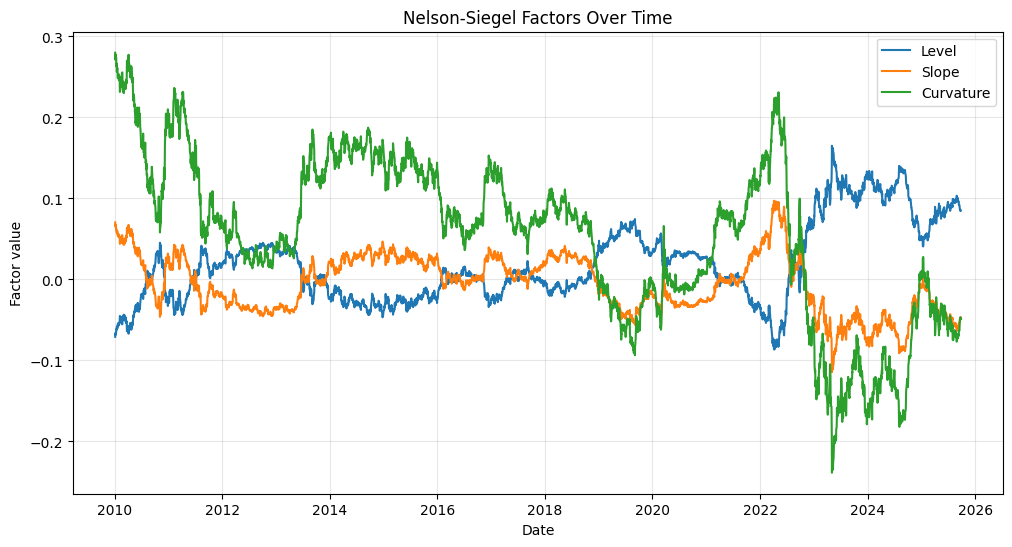

In [118]:
plt.figure(figsize=(12, 6))
plt.plot(df_betas.index, df_betas["Level"], label="Level")
plt.plot(df_betas.index, df_betas["Slope"], label="Slope")
plt.plot(df_betas.index, df_betas["Curvature"], label="Curvature")

plt.xlabel("Date")
plt.ylabel("Factor value")
plt.title("Nelson-Siegel Factors Over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

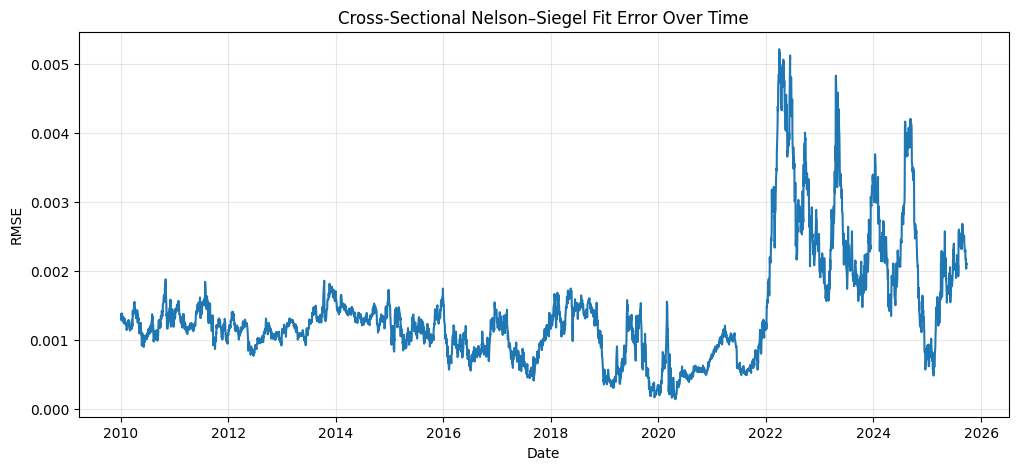

In [119]:
plt.figure(figsize=(12, 5))
plt.plot(df_fit.index, df_fit["RMSE"])

plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("Cross-Sectional Nelson–Siegel Fit Error Over Time")
plt.grid(True, alpha=0.3)
plt.show()

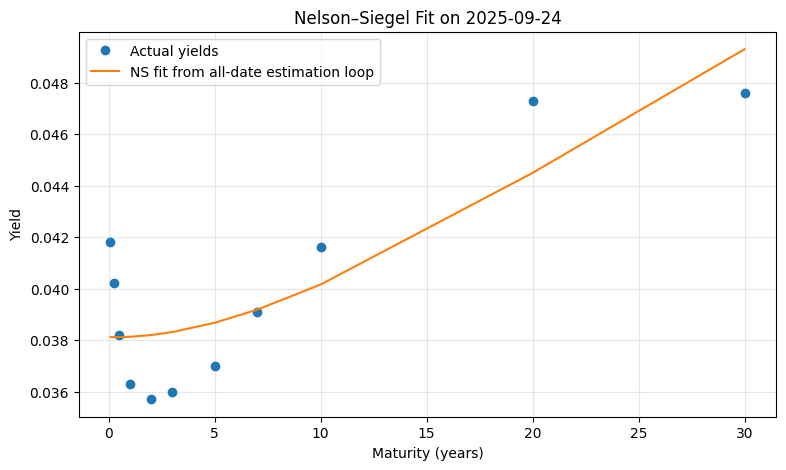

In [120]:
# Pick one date to inspect from the full-sample beta estimates
date = pd.Timestamp("2025-09-24")

y_actual = df_yields.loc[date].to_numpy()
beta_t = df_betas.loc[date].to_numpy()
y_fit_t = L @ beta_t

plt.figure(figsize=(9, 5))
plt.plot(tau, y_actual, 'o', label='Actual yields')
plt.plot(tau, y_fit_t, '-', label='NS fit from all-date estimation loop')

plt.xlabel("Maturity (years)")
plt.ylabel("Yield")
plt.title(f"Nelson–Siegel Fit on {date.date()}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation

- **Level** captures broad shifts in the entire curve
- **Slope** mainly affects the short end relative to the long end
- **Curvature** captures hump-shaped medium-term behavior
- **RMSE** shows how well the 3-factor Nelson–Siegel structure matches each day's cross section

This is still not full DNS yet. At this stage, the factors are estimated independently date by date. The next step is to model these factors dynamically through time.